# DSN AI BOOTCAMP 2026 QUALIFIER PROJECT

## Problem statement
- DSN Mart operates a chain of stores across Nigeria, from small corner shops to flagship hypermarkets, spread across major urban centres, state capitals, and smaller towns. Like any growing retail business, DSN Mart wants to understand what drives sales at the product level across its different store formats and locations, so it can plan stock, pricing, and store investment more intelligently. Build a machine learning model that predicts total sales for a given product at a given store, based on what's known about the product and the outlet it's sold in. 

# 1. Reading train and test datasets, and also trying to get familiar with my dataset

In [1]:
## Import all important libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
%matplotlib inline

In [2]:
# reading the train data using pandas module.
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [3]:
train_df.head()

,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,row_00003,PRD-UN5Z3J,NaN,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36


In [4]:
test_df

,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format
0,row_00009,PRD-2WLNC8,8.628,Low Fat,0.0167,household,190.72,STORE-HL7,23,Medium,Tier_3,Superstore
1,row_00015,PRD-LV9PLM,6.993,Low Fat,0.0579,Health and Hygiene,261.07,STORE-9RG,28,Small,Tier_2,Standard Supermarket
2,row_00019,PRD-ET6ZI7,NaN,Low Fat,0.1262,FRUITS AND VEGETABLES,112.50,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket
3,row_00020,PRD-6RX35U,14.034,Regular,0.0761,frozen foods,200.71,STORE-DKU,30,NaN,Tier_2,Standard Supermarket
4,row_00023,PRD-I4J38V,13.063,Low Fat,0.0650,Frozen Foods,150.59,STORE-89Z,33,Medium,Tier_1,Standard Supermarket
...,...,...,...,...,...,...,...,...,...,...,...,...
1700,row_08483,PRD-58L9K5,17.919,Low Fat,0.0607,Starchy Foods,168.62,STORE-89Z,33,Medium,Tier_1,Standard Supermarket
1701,row_08489,PRD-0B58ST,16.748,Regular,0.0136,canned,97.26,STORE-JOR,34,NaN,Tier_3,Corner Shop
1702,row_08491,PRD-RH8H90,9.876,Low Fat,0.0239,health and hygiene,183.35,STORE-HL7,23,Medium,Tier_3,Superstore
1703,row_08504,PRD-J51IFI,NaN,Low Fat,0.0221,Breads,166.09,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket


In [5]:
train_df.describe()

,product_weight_kg,shelf_visibility,product_price,store_age_years,total_sales
count,5593.000000,6818.000000,6818.000000,6818.000000,6818.000000
mean,12.850876,0.065527,140.473623,34.178205,2174.756574
std,4.646542,0.051566,62.413513,8.384574,1697.894956
min,4.482000,0.000000,31.110000,23.000000,32.700000
25%,8.750000,0.026600,93.280000,28.000000,834.792500
50%,12.647000,0.053200,142.065000,33.000000,1790.890000
75%,16.894000,0.093400,185.987500,45.000000,3092.587500
max,21.883000,0.320100,273.040000,47.000000,12996.820000


In [6]:
test_df.describe()

,product_weight_kg,shelf_visibility,product_price,store_age_years
count,1399.000000,1705.000000,1705.000000,1705.000000
mean,12.865960,0.068491,143.069490,34.127859
std,4.647713,0.051721,61.888692,8.322650
min,4.693000,0.000000,31.980000,23.000000
25%,8.753000,0.030200,96.560000,28.000000
50%,12.617000,0.056400,144.630000,33.000000
75%,16.915500,0.098400,185.210000,45.000000
max,21.980000,0.302000,270.870000,47.000000


In [7]:
train_df.shape

(6818, 13)

In [8]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   6818 non-null   object 
 1   product_code         6818 non-null   object 
 2   product_weight_kg    5593 non-null   float64
 3   fat_content          6818 non-null   object 
 4   shelf_visibility     6818 non-null   float64
 5   product_category     6818 non-null   object 
 6   product_price        6818 non-null   float64
 7   store_code           6818 non-null   object 
 8   store_age_years      6818 non-null   int64  
 9   store_size           4899 non-null   object 
 10  store_location_tier  6818 non-null   object 
 11  store_format         6818 non-null   object 
 12  total_sales          6818 non-null   float64
dtypes: float64(4), int64(1), object(8)
memory usage: 692.6+ KB


In [9]:
train_df.isna().sum()

id                        0
product_code              0
product_weight_kg      1225
fat_content               0
shelf_visibility          0
product_category          0
product_price             0
store_code                0
store_age_years           0
store_size             1919
store_location_tier       0
store_format              0
total_sales               0
dtype: int64

In [10]:
# Dropping the most useless columns in the dataset.
train_df.drop('id', axis=1, inplace=True)

In [11]:
train_df

,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,PRD-UN5Z3J,NaN,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36
...,...,...,...,...,...,...,...,...,...,...,...,...
6813,PRD-V56VKT,9.201,Regular,0.2851,Fruits and Vegetables,136.57,STORE-JOR,34,NaN,Tier_3,Corner Shop,276.50
6814,PRD-S1AWP0,15.770,Low Fat,0.1193,FROZEN FOODS,74.03,STORE-OYG,25,NaN,Tier_2,Standard Supermarket,1265.63
6815,PRD-NCP2VI,17.665,Low Fat,0.0182,Health and Hygiene,234.87,STORE-DKU,30,NaN,Tier_2,Standard Supermarket,6254.55
6816,PRD-K9LSG4,20.645,Low Fat,0.0567,snack foods,118.86,STORE-OYG,25,NaN,Tier_2,Standard Supermarket,1658.06


In [12]:
train_df.describe()

,product_weight_kg,shelf_visibility,product_price,store_age_years,total_sales
count,5593.000000,6818.000000,6818.000000,6818.000000,6818.000000
mean,12.850876,0.065527,140.473623,34.178205,2174.756574
std,4.646542,0.051566,62.413513,8.384574,1697.894956
min,4.482000,0.000000,31.110000,23.000000,32.700000
25%,8.750000,0.026600,93.280000,28.000000,834.792500
50%,12.647000,0.053200,142.065000,33.000000,1790.890000
75%,16.894000,0.093400,185.987500,45.000000,3092.587500
max,21.883000,0.320100,273.040000,47.000000,12996.820000


In [13]:
train_df['product_weight_kg'].isna().sum()

np.int64(1225)

In [14]:
train_df['product_weight_kg'].unique()


array([14.252,  7.698, 14.264, ..., 15.77 , 17.665, 16.703], shape=(4676,))

In [15]:
train_df['product_weight_kg'].mode()

0    7.692
1    8.097
Name: product_weight_kg, dtype: float64

In [16]:
train_df['product_weight_kg'].mean()

np.float64(12.850875916323977)

In [17]:
train_df['product_weight_kg'].value_counts()

product_weight_kg
8.097     5
7.692     5
17.659    4
9.503     4
11.844    4
         ..
7.374     1
18.238    1
11.586    1
14.179    1
16.703    1
Name: count, Length: 4675, dtype: int64

In [18]:
train_df['product_code'].unique()

array(['PRD-PRFP9S', 'PRD-PXXK71', 'PRD-V5MOIJ', ..., 'PRD-AF3WE8',
       'PRD-06GUU9', 'PRD-7Q5FPH'], shape=(1555,), dtype=object)

In [19]:
train_df['product_code'].mode()[0]

'PRD-YZB4K8'

In [20]:
train_df['store_code'].unique()

array(['STORE-AGY', 'STORE-YLW', 'STORE-89Z', 'STORE-7WS', 'STORE-9RG',
       'STORE-HL7', 'STORE-JOR', 'STORE-T5G', 'STORE-OYG', 'STORE-DKU'],
      dtype=object)

In [21]:
train_df['store_code'].value_counts()

store_code
STORE-YLW    754
STORE-9RG    752
STORE-AGY    748
STORE-7WS    748
STORE-OYG    744
STORE-HL7    742
STORE-DKU    736
STORE-89Z    728
STORE-JOR    439
STORE-T5G    427
Name: count, dtype: int64

In [22]:
train_df[train_df['store_code']=='STORE-YLW']

,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
1,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
13,PRD-PGW90J,13.812,Low Fat,0.0431,Dairy,52.83,STORE-YLW,35,Small,Tier_1,Standard Supermarket,585.91
23,PRD-2YAZQT,15.428,Regular,0.0819,Frozen Foods,48.98,STORE-YLW,35,Small,Tier_1,Standard Supermarket,753.42
24,PRD-Q8LYYX,11.265,Regular,0.0735,Frozen Foods,171.96,STORE-YLW,35,Small,Tier_1,Standard Supermarket,2442.31
29,PRD-2SLHIM,20.799,Low Fat,0.0099,Meat,187.29,STORE-YLW,35,Small,Tier_1,Standard Supermarket,536.28
...,...,...,...,...,...,...,...,...,...,...,...,...
6797,PRD-R04H5W,19.232,Low Fat,0.0000,household,190.57,STORE-YLW,35,Small,Tier_1,Standard Supermarket,555.26
6806,PRD-LJKPHC,18.780,Regular,0.0958,Fruits and Vegetables,82.59,STORE-YLW,35,Small,Tier_1,Standard Supermarket,1124.02
6809,PRD-I67HN3,20.547,Low Fat,0.0102,Household,233.74,STORE-YLW,35,Small,Tier_1,Standard Supermarket,3212.38
6812,PRD-JNODL5,18.365,Low Fat,0.0154,Health and Hygiene,161.04,STORE-YLW,35,Small,Tier_1,Standard Supermarket,1588.25


In [23]:
train_df

,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,PRD-UN5Z3J,NaN,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36
...,...,...,...,...,...,...,...,...,...,...,...,...
6813,PRD-V56VKT,9.201,Regular,0.2851,Fruits and Vegetables,136.57,STORE-JOR,34,NaN,Tier_3,Corner Shop,276.50
6814,PRD-S1AWP0,15.770,Low Fat,0.1193,FROZEN FOODS,74.03,STORE-OYG,25,NaN,Tier_2,Standard Supermarket,1265.63
6815,PRD-NCP2VI,17.665,Low Fat,0.0182,Health and Hygiene,234.87,STORE-DKU,30,NaN,Tier_2,Standard Supermarket,6254.55
6816,PRD-K9LSG4,20.645,Low Fat,0.0567,snack foods,118.86,STORE-OYG,25,NaN,Tier_2,Standard Supermarket,1658.06


# 2. Missing Values Handling/Data Cleaning

## Resolving missing values in product_weight_kg
- The same product_code appears in multiple rows meaning a product is sold at different stores, so if the weight is known for that product anywhere else, we can find the actual value instead of guessing one for it.

In [24]:
# now, let's normalize category casing on both test data like it was on train data.
train_df['product_category'] = train_df['product_category'].str.strip().str.lower()
test_df['product_category'] = test_df['product_category'].str.strip().str.lower()

In [25]:
# category lookups from the train notebook.
weight_by_code = train_df.groupby('product_code')['product_weight_kg'].median()
weight_by_category = train_df.groupby('product_category')['product_weight_kg'].median()
weight_global_median = train_df['product_weight_kg'].median()

In [26]:
def fill_weight(row):
    if pd.notna(row['product_weight_kg']):
        return row['product_weight_kg']
    if row['product_code'] in weight_by_code.index and pd.notna(weight_by_code[row['product_code']]):
        return weight_by_code[row['product_code']]
    if row['product_category'] in weight_by_category.index:
        return weight_by_category[row['product_category']]
    return weight_global_median

In [27]:
train_df['product_weight_kg'] = train_df.apply(fill_weight, axis=1)

In [28]:
test_df['product_weight_kg'] = test_df.apply(fill_weight, axis=1)

In [29]:
known = train_df.dropna(subset=['store_size'])
combo_mode = known.groupby(['store_format', 'store_location_tier'])['store_size'].agg(lambda x: x.mode()[0])
format_mode = known.groupby('store_format')['store_size'].agg(lambda x: x.mode()[0])
global_mode = known['store_size'].mode()[0]

In [30]:
def fill_store_size(row):
    if pd.notna(row['store_size']):
        return row['store_size']
    key = (row['store_format'], row['store_location_tier'])
    if key in combo_mode.index:
        return combo_mode[key]
    if row['store_format'] in format_mode.index:
        return format_mode[row['store_format']]
    return global_mode

In [31]:
train_df['store_size'] = train_df.apply(fill_store_size, axis=1)

In [32]:
test_df['store_size'] = test_df.apply(fill_store_size, axis=1)

In [33]:
train_df['product_weight_kg'].isna().sum()

np.int64(0)

In [34]:
train_df.isnull().sum()

product_code           0
product_weight_kg      0
fat_content            0
shelf_visibility       0
product_category       0
product_price          0
store_code             0
store_age_years        0
store_size             0
store_location_tier    0
store_format           0
total_sales            0
dtype: int64

In [35]:
train_df


,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,PRD-PRFP9S,14.252,Low Fat,0.0271,frozen foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,PRD-PXXK71,7.698,Low Fat,0.0720,health and hygiene,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,PRD-V5MOIJ,14.264,Regular,0.0421,canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,PRD-UN5Z3J,12.665,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36
...,...,...,...,...,...,...,...,...,...,...,...,...
6813,PRD-V56VKT,9.201,Regular,0.2851,fruits and vegetables,136.57,STORE-JOR,34,Small,Tier_3,Corner Shop,276.50
6814,PRD-S1AWP0,15.770,Low Fat,0.1193,frozen foods,74.03,STORE-OYG,25,Small,Tier_2,Standard Supermarket,1265.63
6815,PRD-NCP2VI,17.665,Low Fat,0.0182,health and hygiene,234.87,STORE-DKU,30,Small,Tier_2,Standard Supermarket,6254.55
6816,PRD-K9LSG4,20.645,Low Fat,0.0567,snack foods,118.86,STORE-OYG,25,Small,Tier_2,Standard Supermarket,1658.06


In [36]:
# Checking the relationship between location of a store and its size.
pd.crosstab(train_df['store_location_tier'], train_df['store_size'], dropna=False)

store_size,Large,Medium,Small
store_location_tier,,,
Tier_1,0,728,1181
Tier_2,0,0,2232
Tier_3,748,1490,439


In [37]:
train_df

,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,PRD-PRFP9S,14.252,Low Fat,0.0271,frozen foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,PRD-PXXK71,7.698,Low Fat,0.0720,health and hygiene,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,PRD-V5MOIJ,14.264,Regular,0.0421,canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,PRD-UN5Z3J,12.665,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36
...,...,...,...,...,...,...,...,...,...,...,...,...
6813,PRD-V56VKT,9.201,Regular,0.2851,fruits and vegetables,136.57,STORE-JOR,34,Small,Tier_3,Corner Shop,276.50
6814,PRD-S1AWP0,15.770,Low Fat,0.1193,frozen foods,74.03,STORE-OYG,25,Small,Tier_2,Standard Supermarket,1265.63
6815,PRD-NCP2VI,17.665,Low Fat,0.0182,health and hygiene,234.87,STORE-DKU,30,Small,Tier_2,Standard Supermarket,6254.55
6816,PRD-K9LSG4,20.645,Low Fat,0.0567,snack foods,118.86,STORE-OYG,25,Small,Tier_2,Standard Supermarket,1658.06


In [38]:
train_df['product_category']

0                frozen foods
1          health and hygiene
2                      canned
3                 soft drinks
4                        meat
                ...          
6813    fruits and vegetables
6814             frozen foods
6815       health and hygiene
6816              snack foods
6817                household
Name: product_category, Length: 6818, dtype: object

In [39]:
train_df

,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,PRD-PRFP9S,14.252,Low Fat,0.0271,frozen foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,PRD-PXXK71,7.698,Low Fat,0.0720,health and hygiene,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,PRD-V5MOIJ,14.264,Regular,0.0421,canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,PRD-UN5Z3J,12.665,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36
...,...,...,...,...,...,...,...,...,...,...,...,...
6813,PRD-V56VKT,9.201,Regular,0.2851,fruits and vegetables,136.57,STORE-JOR,34,Small,Tier_3,Corner Shop,276.50
6814,PRD-S1AWP0,15.770,Low Fat,0.1193,frozen foods,74.03,STORE-OYG,25,Small,Tier_2,Standard Supermarket,1265.63
6815,PRD-NCP2VI,17.665,Low Fat,0.0182,health and hygiene,234.87,STORE-DKU,30,Small,Tier_2,Standard Supermarket,6254.55
6816,PRD-K9LSG4,20.645,Low Fat,0.0567,snack foods,118.86,STORE-OYG,25,Small,Tier_2,Standard Supermarket,1658.06


In [40]:
train_df.isnull().sum()

product_code           0
product_weight_kg      0
fat_content            0
shelf_visibility       0
product_category       0
product_price          0
store_code             0
store_age_years        0
store_size             0
store_location_tier    0
store_format           0
total_sales            0
dtype: int64

In [41]:
train_df.columns

Index(['product_code', 'product_weight_kg', 'fat_content', 'shelf_visibility',
       'product_category', 'product_price', 'store_code', 'store_age_years',
       'store_size', 'store_location_tier', 'store_format', 'total_sales'],
      dtype='object')

In [42]:
train_df.shape

(6818, 12)

In [43]:
train_df.columns

Index(['product_code', 'product_weight_kg', 'fat_content', 'shelf_visibility',
       'product_category', 'product_price', 'store_code', 'store_age_years',
       'store_size', 'store_location_tier', 'store_format', 'total_sales'],
      dtype='object')

In [44]:
train_df.dtypes

product_code            object
product_weight_kg      float64
fat_content             object
shelf_visibility       float64
product_category        object
product_price          float64
store_code              object
store_age_years          int64
store_size              object
store_location_tier     object
store_format            object
total_sales            float64
dtype: object

In [45]:
train_df['shelf_visibility'].astype(int)

0       0
1       0
2       0
3       0
4       0
       ..
6813    0
6814    0
6815    0
6816    0
6817    0
Name: shelf_visibility, Length: 6818, dtype: int64

In [46]:
train_df['total_sales'].astype(int)

0       1764
1        342
2        378
3       5595
4       2375
        ... 
6813     276
6814    1265
6815    6254
6816    1658
6817     987
Name: total_sales, Length: 6818, dtype: int64

In [47]:
train_df['product_price'].astype(int)

0        81
1        42
2        41
3       174
4       203
       ... 
6813    136
6814     74
6815    234
6816    118
6817     97
Name: product_price, Length: 6818, dtype: int64

In [48]:
train_df['product_weight_kg'].astype(int)

0       14
1        7
2       14
3       12
4       10
        ..
6813     9
6814    15
6815    17
6816    20
6817    16
Name: product_weight_kg, Length: 6818, dtype: int64

In [49]:
train_df

,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,PRD-PRFP9S,14.252,Low Fat,0.0271,frozen foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,PRD-PXXK71,7.698,Low Fat,0.0720,health and hygiene,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,PRD-V5MOIJ,14.264,Regular,0.0421,canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,PRD-UN5Z3J,12.665,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36
...,...,...,...,...,...,...,...,...,...,...,...,...
6813,PRD-V56VKT,9.201,Regular,0.2851,fruits and vegetables,136.57,STORE-JOR,34,Small,Tier_3,Corner Shop,276.50
6814,PRD-S1AWP0,15.770,Low Fat,0.1193,frozen foods,74.03,STORE-OYG,25,Small,Tier_2,Standard Supermarket,1265.63
6815,PRD-NCP2VI,17.665,Low Fat,0.0182,health and hygiene,234.87,STORE-DKU,30,Small,Tier_2,Standard Supermarket,6254.55
6816,PRD-K9LSG4,20.645,Low Fat,0.0567,snack foods,118.86,STORE-OYG,25,Small,Tier_2,Standard Supermarket,1658.06


# 3. EDA
- We'll be checking the relationships between cateorical features and numerical features.
- We'll be checking the relationships between numerical features.
- We'll be checking the relationship numerical features has with itself likewise categorical features also has with itself.
- We'll be checking the skewness of the data, pinpointing outliers also. 

## - Starting with the numerical columns/features.

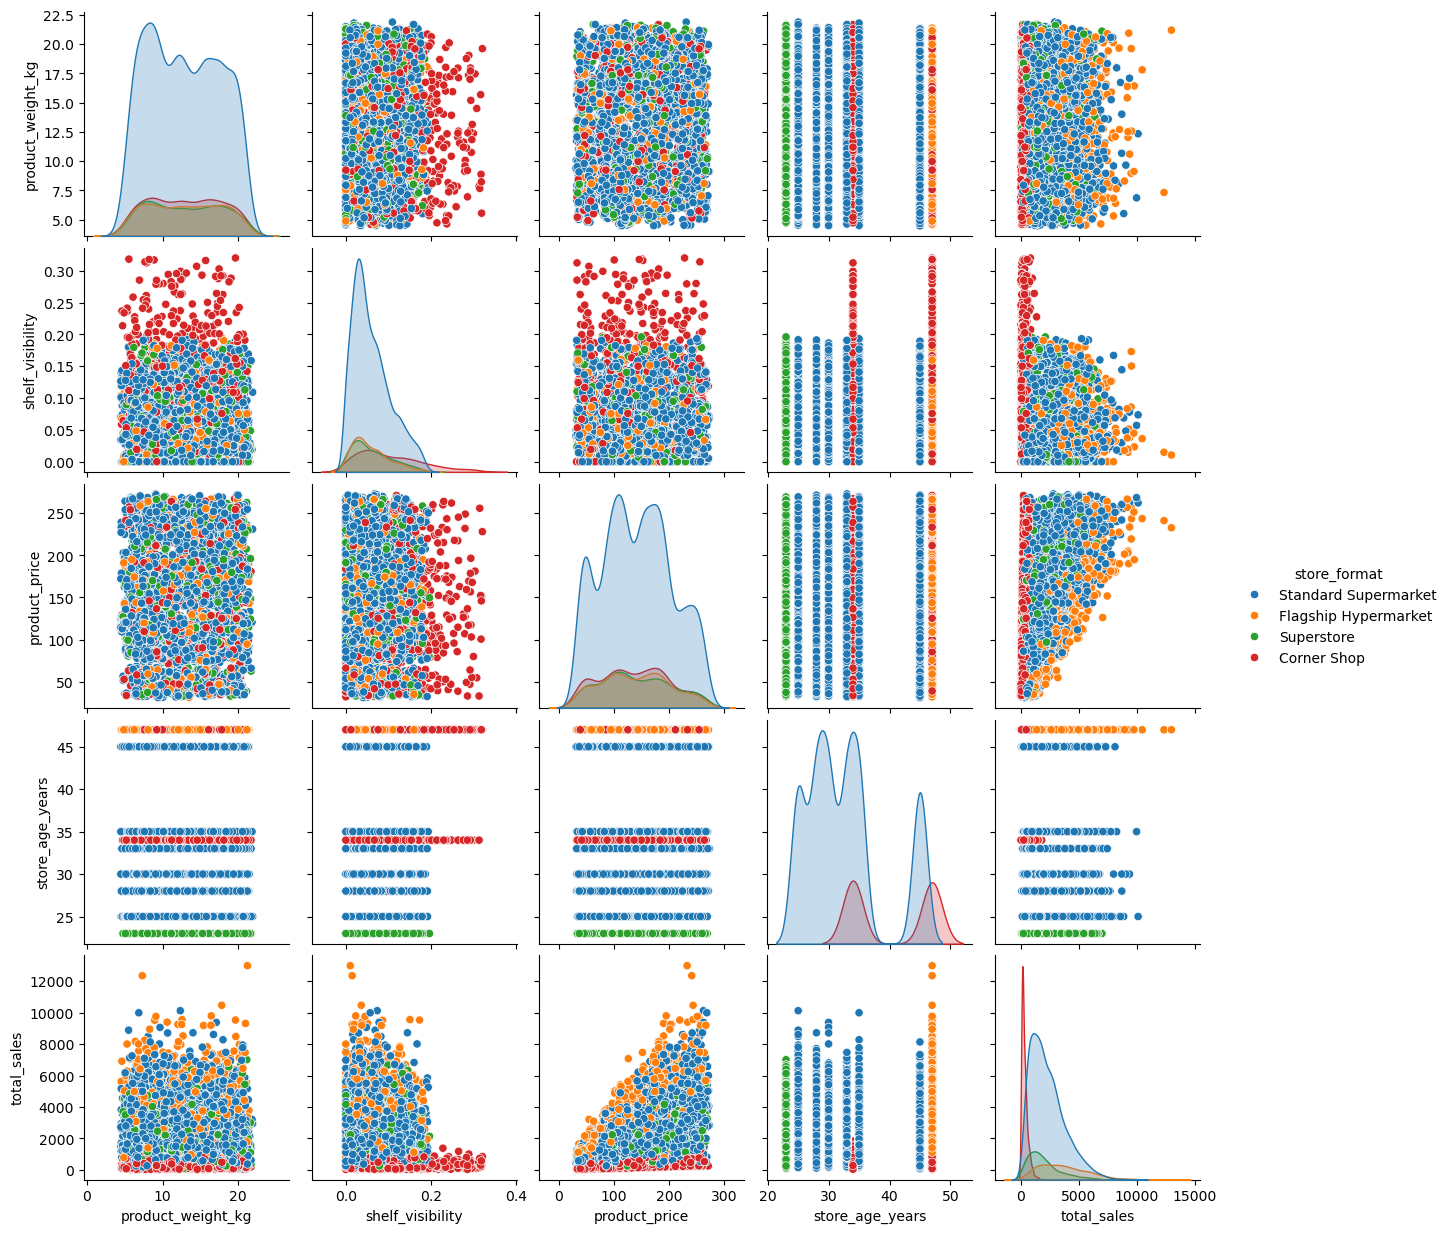

In [50]:
sns.pairplot(train_df, hue='store_format')

- As always, pairplot always end up confusing me because of too many plots embedded at once. so, for the sake of clarity, i'll check out what the data says by plotting graphs with less features at once.

## - Checking for skewness in the numerical columns and afterwards i'll check for outliers.

In [51]:
num_cols = ['product_weight_kg', 'shelf_visibility', 'product_price', 'store_age_years', 'total_sales']

### - Let's see how the datas are looking on plots.
- Let's check if each number column is balanced or lopsided.

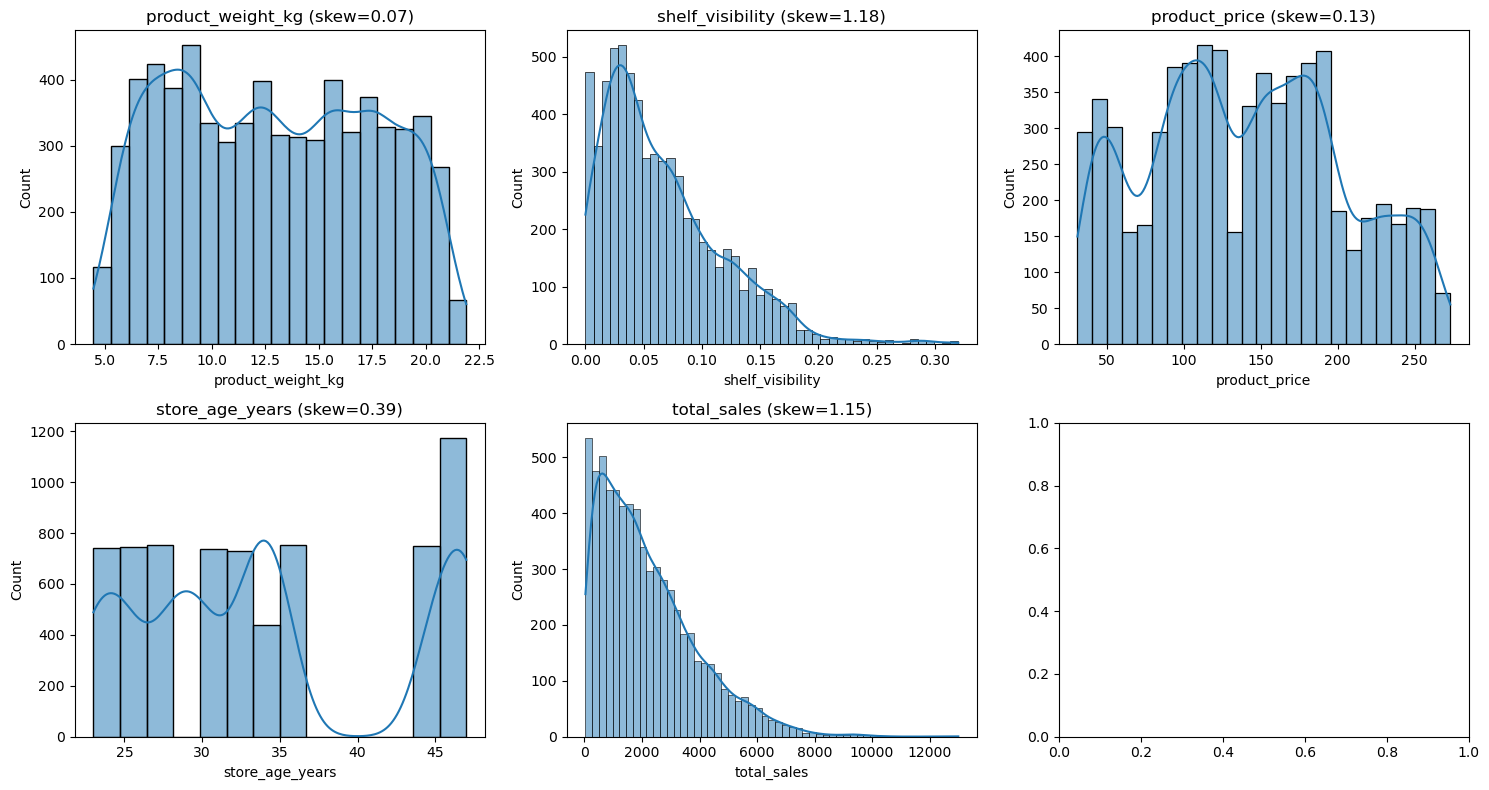

In [52]:
# distribution shape
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(train_df[col], kde=True, ax=ax)
    ax.set_title(f'{col} (skew={train_df[col].skew():.2f})')
plt.tight_layout()

- Looking at the plots above: `product_weight_kg`, `product_price`, and `store_age_years` all look pretty balanced — nothing weird going on. But `shelf_visibility` and `total_sales` are lopsided — most values are small, with a few really big ones stretching the tail out to the right and pulling the average up.

`shelf_visibility` and `total_sales` were the lopsided ones, so let's dig more grounds on those two and see if there are any extreme values sitting way outside the normal range.

<Axes: xlabel='total_sales'>

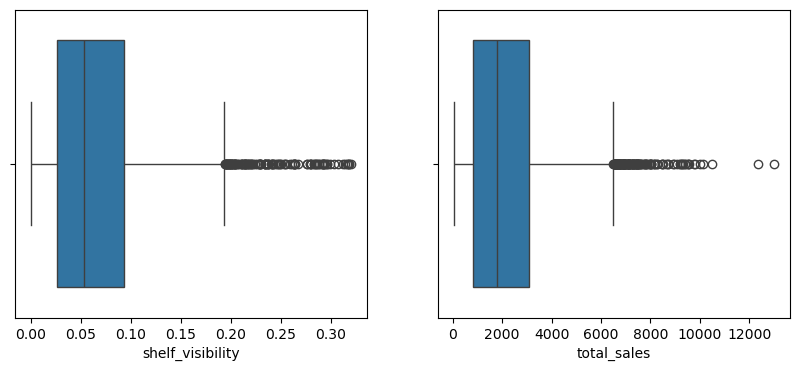

In [53]:
# Checking for Outliers in my train dataset
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(x=train_df['shelf_visibility'], ax=axes[0])
sns.boxplot(x=train_df['total_sales'], ax=axes[1])

- As expected, both columns have a whole lot of dots sitting above the box, meaning real outliers. I'm not deleting them though. In real store data, it's totally normal for a handful of products or stores to massively outsell everyone else, so these are probably genuine high performers, not mistakes in the data.

## - Now unto the Categorical columns.

Now let's see how the category-type columns are distributed — is each one fairly balanced, or do some values show up way more than others?

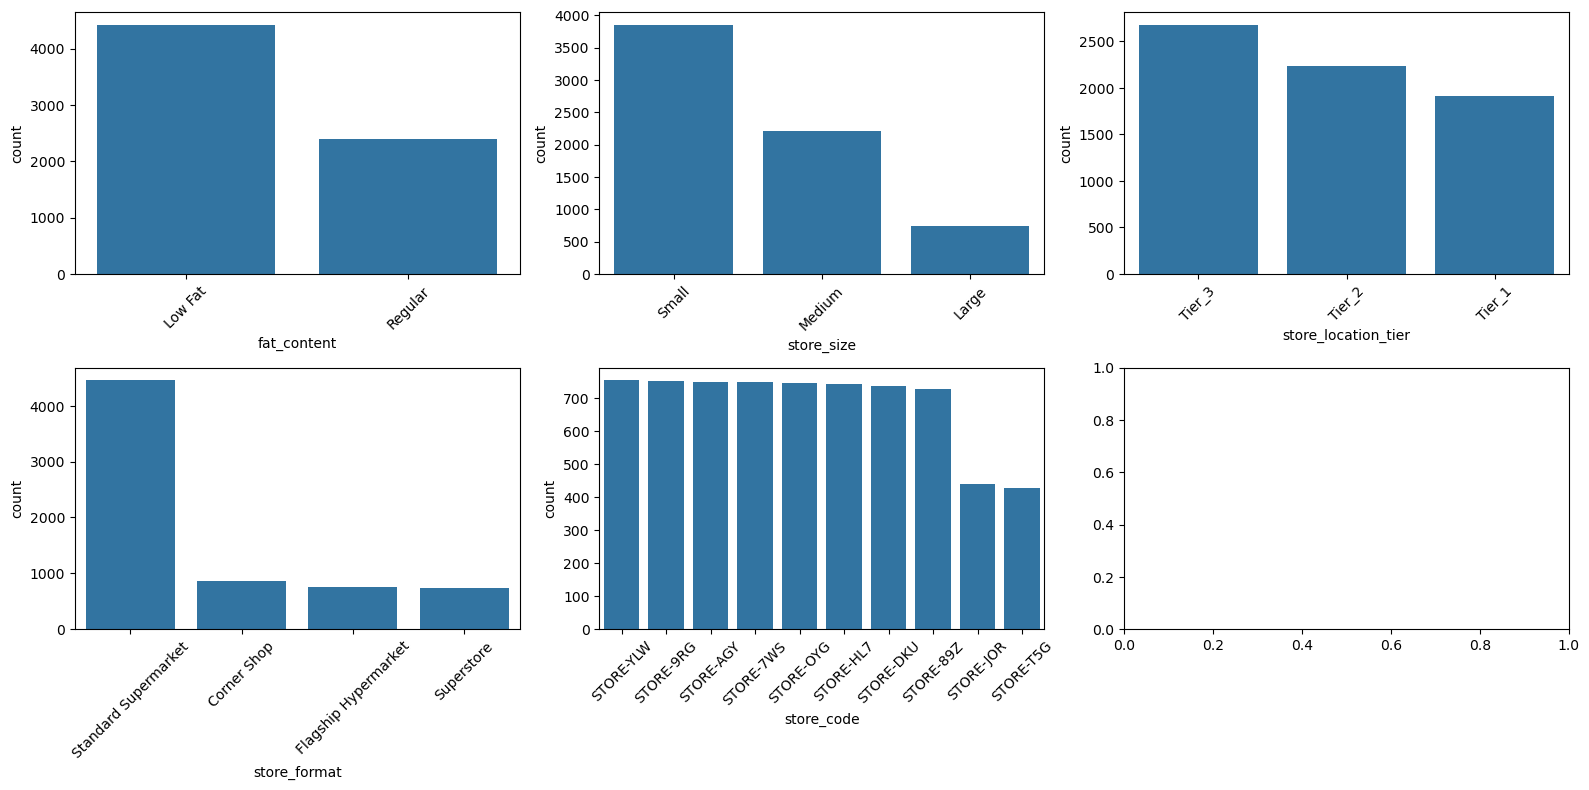

In [54]:
# I want to explore what the categorical columns look like on plots
cat_cols = ['fat_content', 'store_size', 'store_location_tier', 'store_format', 'store_code']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), cat_cols):
    sns.countplot(data=train_df, x=col, ax=ax, order=train_df[col].value_counts().index)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()

- `fat_content` is basically split down the middle between `Low Fat` and `Regular`.  Most of the 10 stores have a similar number of rows, except two (`STORE-JOR` and `STORE-T5G`) which have noticeably fewer. These are the same two stores that were missing `store_size` earlier.

<Axes: xlabel='count', ylabel='product_category'>

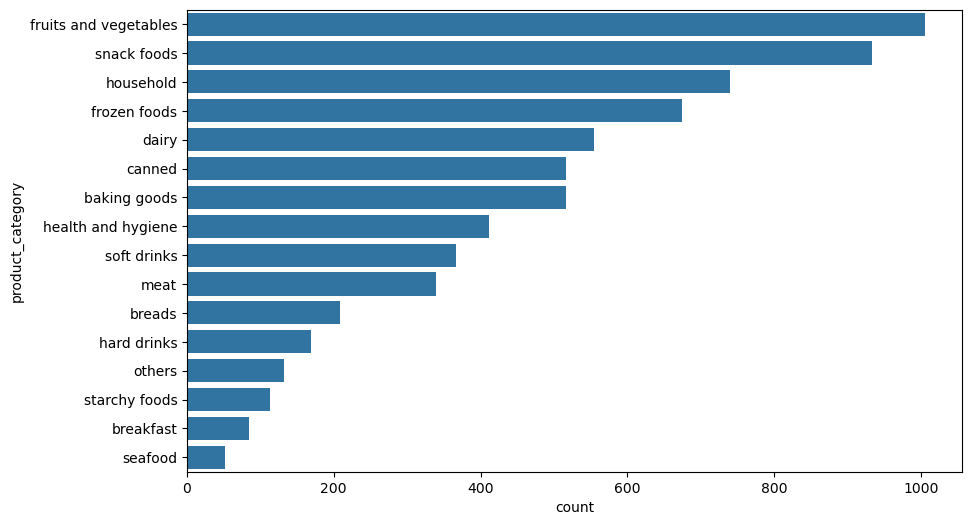

In [55]:
plt.figure(figsize=(10, 6))
sns.countplot(data=train_df, y='product_category', order=train_df['product_category'].value_counts().index)

- `product_category` isn't balanced at all though. for example, `fruits and vegetables` and `snack foods` show up the most, while `seafood` and `breakfast` barely show up.

## - I've done so many plots, but one question remains unanswered. How does each feature relate to the total sales??
- The answer will be at the next cells.

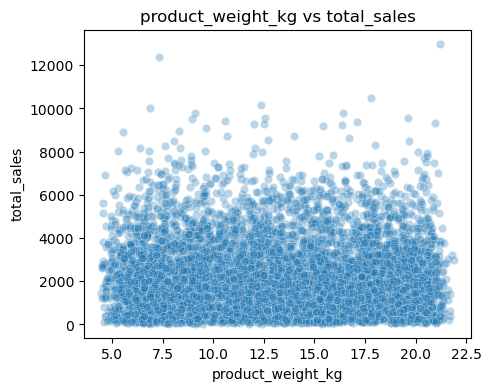

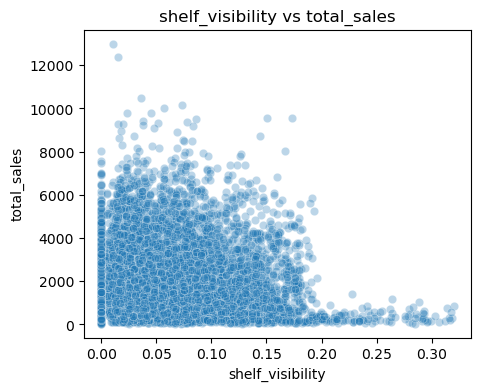

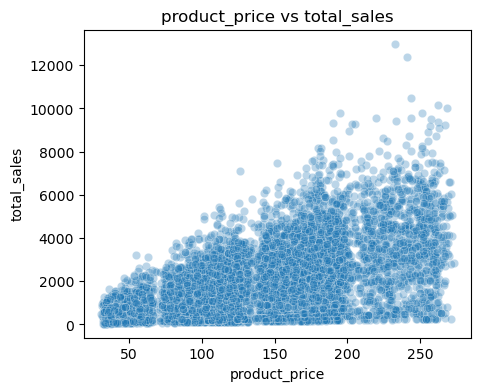

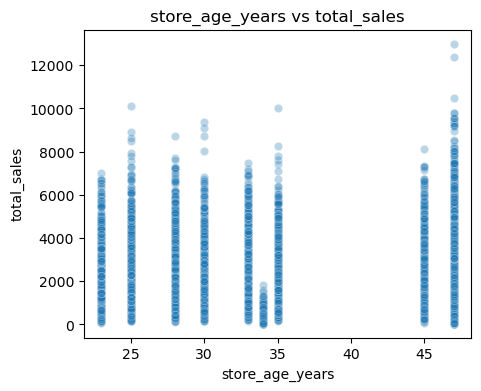

In [56]:
# Plots of numerical datas vs total_sales
for col in ['product_weight_kg', 'shelf_visibility', 'product_price', 'store_age_years']:
    plt.figure(figsize=(5, 4))
    sns.scatterplot(data=train_df, x=col, y='total_sales', alpha=0.3)
    plt.title(f'{col} vs total_sales')

- `product_price` stood out the most; higher price generally lines up with higher sales. `store_age_years` and `product_weight_kg` barely seem to matter on their own. `shelf_visibility` actually had a slight negative connection with sales, which is a little surprising, but I'm just noting it, not trying to explain it away.

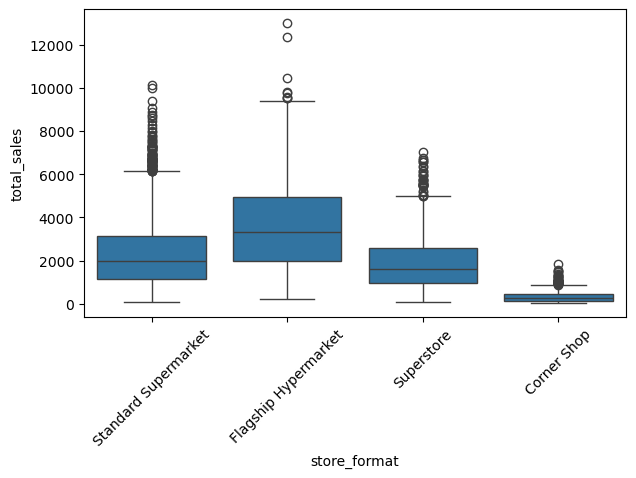

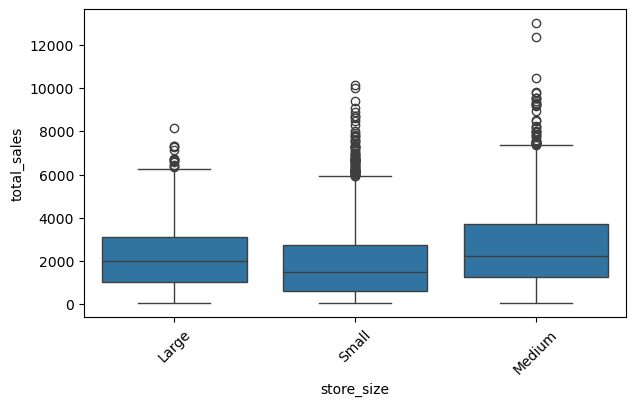

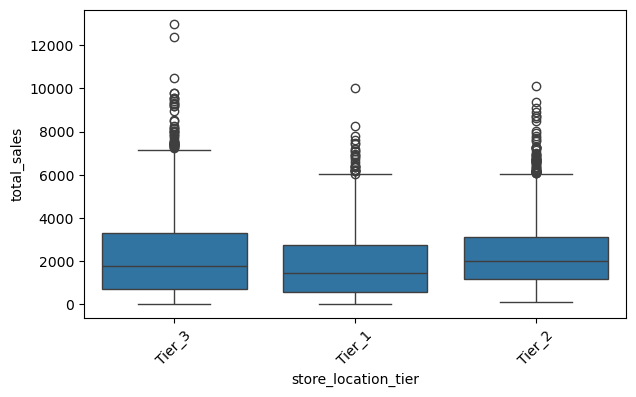

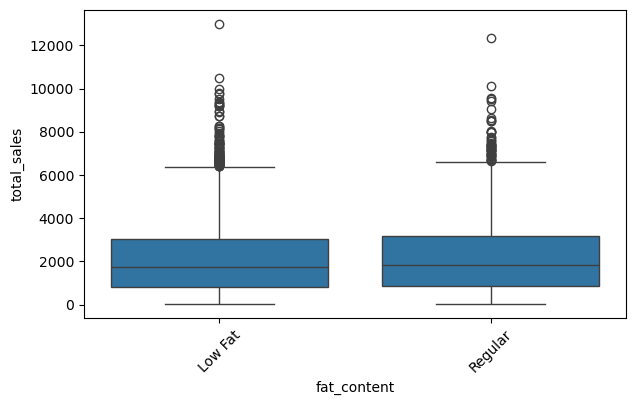

In [57]:
## Categorical features against the target feature.
for col in ['store_format', 'store_size', 'store_location_tier', 'fat_content']:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=train_df, x=col, y='total_sales')
    plt.xticks(rotation=45)

- For the category columns: `store_format` made the biggest difference by far — `Flagship Hypermarket` stores sell way more on average than `Corner Shop` stores (more than 10x higher). `store_size` and `store_location_tier` also showed some difference, with `Medium` stores and `Tier_2` locations doing best. `fat_content` barely made any difference, so it's probably not a big deal for predicting sales.

<Axes: >

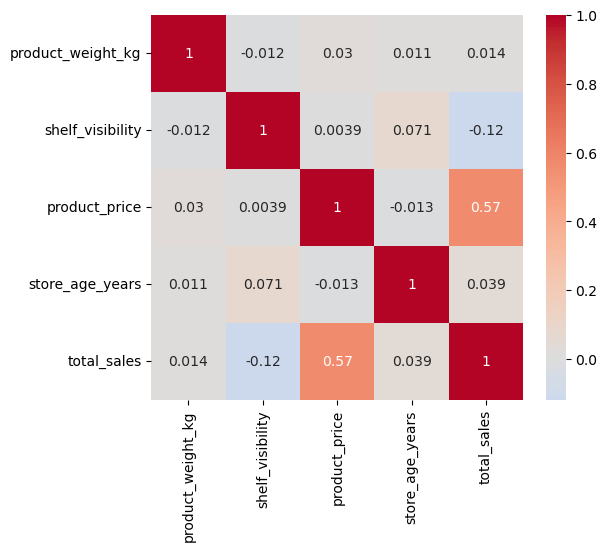

In [58]:
## Numerical columns against the correlation of the Numeric columns.
plt.figure(figsize=(6, 5))
sns.heatmap(train_df[num_cols].corr(), annot=True, cmap='coolwarm', center=0)

- They're not overlapping. all the numerical columns are pretty independent of each other. That's good news, it means each one brings its own unique information instead of repeating what another column already tells us.

## What I Learned From All This

- `product_price` and `store_format` seem to matter the most for predicting sales.
- Things like `product_weight_kg` and `store_age_years` don't seem to matter much on their own.
- `total_sales` and `shelf_visibility` are lopsided and have some big outlier values, something to keep in mind before building a model.
- Some categories (like product type and store) aren't evenly represented, so that's something to watch out for later.


# 4. Train data Encoding

- One Hot Encoding alongside Ordinal Encoding was used here.

In [59]:
# setting the categorical columns up.
size_order = ['Small', 'Medium', 'Large']
tier_order = ['Tier_1', 'Tier_2', 'Tier_3']

In [60]:
# This is where Ordinal Encoding was used.
for df in [train_df, test_df]:
    df['store_size'] = pd.Categorical(df['store_size'], categories=size_order, ordered=True).codes
    df['store_location_tier'] = pd.Categorical(df['store_location_tier'], categories=tier_order, ordered=True).codes

In [61]:
train_df['store_size'].unique()

array([2, 0, 1], dtype=int8)

In [62]:
train_df['store_location_tier'].unique()

array([2, 0, 1], dtype=int8)

In [63]:
# This is where One Hot Encoding was used.
cat_cols = ['fat_content', 'store_format', 'product_category', 'store_code']
combined = pd.concat([train_df[cat_cols], test_df[cat_cols]], keys=['train', 'test'])
combined_encoded = pd.get_dummies(combined, columns=cat_cols, drop_first=True)

In [64]:
train_encoded = combined_encoded.loc['train'].reset_index(drop=True)
test_encoded = combined_encoded.loc['test'].reset_index(drop=True)

In [65]:
train_df = pd.concat([train_df.drop(columns=cat_cols).reset_index(drop=True), train_encoded], axis=1)
test_df = pd.concat([test_df.drop(columns=cat_cols).reset_index(drop=True), test_encoded], axis=1)

In [66]:
# i dropped the product_code column because it doesn't seem to matter much to my work.
train_df = train_df.drop(columns=['product_code'])
test_df = test_df.drop(columns=['product_code'])

In [67]:
# checking the shape of the train and test data.
print('train_df shape:', train_df.shape, '| test_df shape:', test_df.shape)

train_df shape: (6818, 35) | test_df shape: (1705, 35)


## I have successfully encoded the store size, store location and store code columns using One Hot Encoding and Ordinal Encoding.
- I used One Hot Encoding because i need each column to represent each stores.
- Then, i used Ordinal Encoding because the data are basically hierachical.

# 5. Modelling and Prediction

In [68]:
# importing libraries from scikit-learn
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor, AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import numpy as np

In [69]:
X = train_df.drop(columns=['total_sales'])
y = train_df['total_sales']

## I tried my base model Linear Regression.

In [70]:
format_cols = [c for c in X.columns if c.startswith('store_format_')]
X_lin = X.copy()
X_test_final = test_df.drop(columns=['id'])
for c in format_cols:
    X_lin[f'{c}_x_price'] = X_lin[c] * X_lin['product_price']

for c in format_cols:
    X_test_final[f'{c}_x_price'] = X_test_final[c] * X_test_final['product_price']

In [119]:
#Linear Regression
X_train, X_val, y_train, y_val = train_test_split(X_lin, y, test_size=0.2, random_state=42)
X_train_lin, X_val_lin, _, _ = train_test_split(X_lin, y, test_size=0.2, random_state=42)
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_rmse = np.sqrt(mean_squared_error(y_val, lr.predict(X_val)))
print('Linear Regression (with interaction) RMSE:', lr_rmse)

Linear Regression (with interaction) RMSE: 1061.883583051801


## - Now going after other other algorithms 

In [105]:
sc = StandardScaler().fit(X_train)
X_train_s, X_val_s = sc.transform(X_train), sc.transform(X_val)

In [106]:
def get_rmse(model, Xtr, ytr, Xv, yv):
    model.fit(Xtr, ytr)
    return np.sqrt(mean_squared_error(yv, model.predict(Xv)))

In [107]:
# Looking into my results for observation.
results = {}
results['Linear Regression'] = get_rmse(LinearRegression(), X_train_lin, y_train, X_val_lin, y_val)
results['Ridge'] = get_rmse(Ridge(alpha=1.0), X_train_lin, y_train, X_val_lin, y_val)
results['Lasso'] = get_rmse(Lasso(alpha=1.0), X_train_lin, y_train, X_val_lin, y_val)
results['ElasticNet'] = get_rmse(ElasticNet(alpha=1.0, max_iter=5000), X_train_lin, y_train, X_val_lin, y_val)
results['Random Forest'] = get_rmse(RandomForestRegressor(n_estimators=300, max_depth=5, min_samples_leaf=40, random_state=42, n_jobs=-1), X_train, y_train, X_val, y_val)
results['Extra Trees'] = get_rmse(ExtraTreesRegressor(n_estimators=300, random_state=42, n_jobs=-1), X_train, y_train, X_val, y_val)
results['Gradient Boosting'] = get_rmse(GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42), X_train, y_train, X_val, y_val)
results['HistGradientBoosting'] = get_rmse(HistGradientBoostingRegressor(random_state=42), X_train, y_train, X_val, y_val)
results['AdaBoost'] = get_rmse(AdaBoostRegressor(random_state=42), X_train, y_train, X_val, y_val)
results['KNN (k=5, scaled)'] = get_rmse(KNeighborsRegressor(n_neighbors=5), X_train_s, y_train, X_val_s, y_val)
results['SVR (scaled)'] = get_rmse(SVR(), X_train_s, y_train, X_val_s, y_val)

for name, r in sorted(results.items(), key=lambda x: x[1]):
    print(f'{name:35s} RMSE={r:8.2f}')

Lasso                               RMSE= 1038.47
Ridge                               RMSE= 1038.89
Linear Regression                   RMSE= 1038.90
ElasticNet                          RMSE= 1039.09
Random Forest                       RMSE= 1057.56
Gradient Boosting                   RMSE= 1067.42
HistGradientBoosting                RMSE= 1081.12
Extra Trees                         RMSE= 1160.14
KNN (k=5, scaled)                   RMSE= 1215.44
AdaBoost                            RMSE= 1266.96
SVR (scaled)                        RMSE= 1745.09


## Findings from the results prediction:
- The linear models (Linear Regression, Ridge, Lasso, ElasticNet) came out clearly ahead of every tree-based and distance-based model once the `store_format vs price` interaction is included, all clustered close together at the top, while KNN, SVR, and AdaBoost performed noticeably worse without more tuning. This suggests the relationship between the features and `total_sales` is mostly linear, so the extra flexibility of the trees models isn't adding much of value here.

## - I'll be trying some hyperparameter tuning on the top models
- Since the linear-family models were closest together, that's where tuning the regularization strength (`alpha`) is most likely to make a real difference. Using GridSearchCV with 5-fold cross-validation to iterate over a range of alpha values for Ridge, Lasso, and ElasticNet.

In [108]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

In [109]:
neg_rmse = make_scorer(lambda yt, yp: -np.sqrt(mean_squared_error(yt, yp)))

In [110]:
param_grid_ridge = {'alpha': [0.01, 0.1, 1, 5, 10, 50, 100, 200]}
param_grid_lasso = {'alpha': [0.01, 0.1, 1, 5, 10, 50, 100]}
param_grid_enet = {'alpha': [0.01, 0.1, 1, 5, 10], 'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]}

In [111]:
tuned_results = {}
for name, model, grid in [
    ('Ridge', Ridge(), param_grid_ridge),
    ('Lasso', Lasso(max_iter=5000), param_grid_lasso),
    ('ElasticNet', ElasticNet(max_iter=5000), param_grid_enet)
]:
    gs = GridSearchCV(model, grid, scoring=neg_rmse, cv=5, n_jobs=-1)
    gs.fit(X_train_lin, y_train)
    best_model = gs.best_estimator_
    val_rmse = np.sqrt(mean_squared_error(y_val, best_model.predict(X_val_lin)))
    tuned_results[name] = (best_model, gs.best_params_, val_rmse)
    print(f'{name:12s} best params: {gs.best_params_}  |  Val RMSE: {val_rmse:.2f}')

Ridge        best params: {'alpha': 200}  |  Val RMSE: 1038.21
Lasso        best params: {'alpha': 5}  |  Val RMSE: 1038.40
ElasticNet   best params: {'alpha': 1, 'l1_ratio': 0.9}  |  Val RMSE: 1038.39


- Tuning the regularization strength barely changed the results of the model simply because they all landed within ~1.5 RMSE of their defaults, which suggests that the models weren't overfitting much to begin with. The earlier `store_format x price` interaction was what actually mattered, not the regularization strength.

- Final model: ElasticNet Model with RMSE of 1060.40

In [112]:
final_model = ElasticNet(alpha=1, l1_ratio=0.9, max_iter=5000)
final_model.fit(X_lin, y)

,alpha,1
,l1_ratio,0.9
,fit_intercept,True
,precompute,False
,max_iter,5000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [113]:
X_lin.columns

Index(['product_weight_kg', 'shelf_visibility', 'product_price',
       'store_age_years', 'store_size', 'store_location_tier',
       'fat_content_Regular', 'store_format_Flagship Hypermarket',
       'store_format_Standard Supermarket', 'store_format_Superstore',
       'product_category_breads', 'product_category_breakfast',
       'product_category_canned', 'product_category_dairy',
       'product_category_frozen foods',
       'product_category_fruits and vegetables',
       'product_category_hard drinks', 'product_category_health and hygiene',
       'product_category_household', 'product_category_meat',
       'product_category_others', 'product_category_seafood',
       'product_category_snack foods', 'product_category_soft drinks',
       'product_category_starchy foods', 'store_code_STORE-89Z',
       'store_code_STORE-9RG', 'store_code_STORE-AGY', 'store_code_STORE-DKU',
       'store_code_STORE-HL7', 'store_code_STORE-JOR', 'store_code_STORE-OYG',
       'store_code_STORE-

In [114]:
X_test_final = X_test_final[X_lin.columns]

In [115]:
X_test_final.isnull().sum()

product_weight_kg                            0
shelf_visibility                             0
product_price                                0
store_age_years                              0
store_size                                   0
store_location_tier                          0
fat_content_Regular                          0
store_format_Flagship Hypermarket            0
store_format_Standard Supermarket            0
store_format_Superstore                      0
product_category_breads                      0
product_category_breakfast                   0
product_category_canned                      0
product_category_dairy                       0
product_category_frozen foods                0
product_category_fruits and vegetables       0
product_category_hard drinks                 0
product_category_health and hygiene          0
product_category_household                   0
product_category_meat                        0
product_category_others                      0
product_categ

In [116]:
test_predictions = final_model.predict(X_test_final)

In [117]:
submission = pd.DataFrame({
    'id': test_df['id'],
    'total_sales': test_predictions
})

print(submission.shape)   # should be (1705, 2)
submission.head()

submission.to_csv('submission.csv', index=False)

(1705, 2)
